In [252]:
import numpy as np
import matplotlib.pyplot as plt
from mpdaf.obj import Cube
from astropy.coordinates import SkyCoord
import sys
import os
import plotfancy as pf
from matplotlib.patches import Circle
from astropy.visualization import ZScaleInterval
from astropy.table import Table
from types import SimpleNamespace
import re
from astropy.io import ascii
from astropy import units as u

import logging 
logging.getLogger('mpdaf').setLevel(logging.WARNING)

pf.housestyle_rcparams()

True

In [253]:
def generate_gaussian_profile(params, num_points=500, width_factor=4.0):
    sigma = params.fwhm / (2 * np.sqrt(2 * np.log(2)))
    x_min = params.lpeak - width_factor * params.fwhm / 2
    x_max = params.lpeak + width_factor * params.fwhm / 2
    x = np.linspace(x_min, x_max, num_points)
    y = params.cont + params.peak * np.exp(-((x - params.lpeak) ** 2) / (2 * sigma ** 2))
    return np.vstack((x, y))

def load_cube(path):
    print(f'Loading datacube: {path}...')
    try:
        cube = Cube(path)
        print(f'Successfully loaded cube. Dimensions: {cube.shape}')
        return cube
    except FileNotFoundError:
        print(f'Error: Datacube not found at {path}')
        sys.exit(1)

def extract_spectrum(cube, ra, dec, radius):
    center = (dec, ra)
    print(f'\nExtracting spectrum at (RA, Dec) = ({ra:.6f}, {dec:.6f}) with a {radius}" radius aperture.')
    spec = cube.aperture(center, radius, is_sum=True)
    print('Extraction complete.')
    return spec

def measure_redshift(spec, z_guess):
    print('\nMeasuring spectroscopic redshift...')
    lines_for_z = {'Hbeta': 4861.33, 'OIII_5007': 5006.84, 'Halpha': 6562.80}
    redshifts = []
    for name, rest_wave in lines_for_z.items():
        obs_wave_guess = rest_wave * (1 + z_guess)
        try:
            fit = spec.gauss_fit(lmin=(obs_wave_guess - 30), lmax=(obs_wave_guess + 30), plot=False)
            line_z = (fit.lpeak / rest_wave) - 1
            redshifts.append(line_z)
            print(fr'  - {name}: Found at {fit.lpeak:.2f} \AA, z = {line_z:.5f}')
        except Exception:
            print(fr'  - {name}: Fit failed near {obs_wave_guess:.2f} \AA.')

    if not redshifts:
        print('\nError: Could not measure redshift. Using initial guess.')
        return z_guess, 0.0
    
    z_measured = np.mean(redshifts)
    z_err = np.std(redshifts) / np.sqrt(len(redshifts)) if len(redshifts) > 1 else 0.0
    print(f'\nMeasured Redshift z = {z_measured:.5f} \xB1 {z_err:.5f}')
    return z_measured, z_err

def deredshift_spectrum(spec, z):
    spec_rest = spec.copy()
    spec_rest.wave.set_crval(spec_rest.wave.get_crval() / (1 + z))
    spec_rest.wave.set_step(spec_rest.wave.get_step() / (1 + z))
    return spec_rest

def fit_emission_lines(spec_rest):
    from types import SimpleNamespace
    lines = {'Hbeta': 4861.33, 'OIII_5007': 5006.84, 'Halpha': 6562.80, 'NII_6583': 6583.45}
    line_fits = {}
    for name, wave in lines.items():
        try:
            line_fits[name] = spec_rest.gauss_fit(lmin=(wave - 15), lmax=(wave + 15), plot=False)
        except Exception:
            sub_spec = spec_rest.subspec(lmin=wave - 15, lmax=wave + 15)
            
            spec_for_continuum = None
            if sub_spec is not None and len(sub_spec.shape) == 1 and sub_spec.shape[0] > 2:
                spec_for_continuum = sub_spec
            elif spec_rest is not None and len(spec_rest.shape) == 1 and spec_rest.shape[0] > 2:
                spec_for_continuum = spec_rest

            if spec_for_continuum:
                continuum = np.mean(spec_for_continuum.data)
                std_err = np.std(spec_for_continuum.data)
                
                fit_mock = SimpleNamespace(
                    flux=0.0,
                    err_flux=std_err,
                    peak=0.0,
                    cont=continuum,
                    lpeak=wave,
                    fwhm=1.0,
                    err_peak=std_err,
                    err_cont=std_err,
                    err_lpeak=0.0,
                    err_fwhm=0.0
                )
                line_fits[name] = fit_mock
            else:
                line_fits[name] = None
    return line_fits


In [ ]:
class museCube:
    def __init__(self, path:str):
        ### attributes ###
        self.path = path
        self.title = self._get_title()
        self.spectra = {}
        self.rest_spectra = {}
        ### initialisers ###
        self.init_cube(self.path)
        self.init_lambda()
        self.init_table()

    ### INITIALISERS ###
    def _dirmanagement(self,id):
        if not os.path.isdir(f'figs/{self.title}/{id}'):
            if not os.path.isdir(f'figs/{self.title}'):
                if not os.path.isdir('figs'):
                    os.mkdir(f'figs')
                os.mkdir(f'figs/{self.title}')
            os.mkdir(f'figs/{self.title}/{id}')
            os.mkdir(f'figs/{self.title}/{id}/lines')
        return True

    def _get_title(self):
        pattern = r'cubes/([^_]+)_'
        match = re.search(pattern, self.path)
        if match:
            return match.group(1)
        else:
            return 'BLANK'

    def init_cube(self, PATH):
        print(f'Loading datacube: {PATH}...')
        try:
            cube = Cube(PATH)
            print(f'Successfully loaded cube. Dimensions: {cube.shape}')
            self.cube = cube
            return True
        except FileNotFoundError:
            print(f'Error: Datacube not found at {PATH}')
            sys.exit(1)
    
    def init_lambda(self):
        self.rest_lambdas = {
        # --- Primary [OIII] and [OII] ---
        'oiii5007': 5006.84,
        'oiii4959': 4958.91,
        'oii3726':  3726.03,
        'oii3729':  3728.82,

        # --- Hydrogen Balmer Series ---
        'halpha':   6562.80,
        'hbeta':    4861.33,
        'hgamma':   4340.46,
        'hdelta':   4101.73,

        # --- Key Diagnostic Lines ---
        'oiii4363': 4363.21,
        'neiii':    3868.75,

        # --- Low-Ionization Lines ---
        'nii6583':  6583.45,
        'nii6548':  6548.05,
        'sii6716':  6716.44,
        'sii6731':  6730.82,

        # --- Helium Lines ---
        'heii4686': 4685.68,
        'hei5876':  5875.62,
        }
        self.lambda_keys = {
        # --- Primary [OIII] and [OII] ---
        'oiii5007': r'[OIII] $\lambda$5007',
        'oiii4959': r'[OIII] $\lambda$4959',
        'oii3726':  r'[OII] $\lambda$3726',
        'oii3729':  r'[OII] $\lambda$3729',

        # --- Hydrogen Balmer Series ---
        'halpha':   r'H$\alpha$',
        'hbeta':    r'H$\beta$',
        'hgamma':   r'H$\gamma$',
        'hdelta':   r'H$\delta$',

        # --- Key Diagnostic Lines ---
        'oiii4363': r'[OIII] $\lambda$4363', 
        'neiii':    r'[NeIII] $\lambda$3869',

        # --- Low-Ionization Lines ---
        'nii6583':  r'[NII] $\lambda$6583',
        'nii6548':  r'[NII] $\lambda$6548',
        'sii6716':  r'[SII] $\lambda$6716',
        'sii6731':  r'[SII] $\lambda$6731',

        # --- Helium Lines (not forbidden) ---
        'heii4686': r'HeII $\lambda$4686',
        'hei5876':  r'HeI $\lambda$5876',
        }
        return True
    
    def init_table(self, cnames=None):
        self.column_names = ['object_id', 'ra', 'dec','z'] if cnames==None else cnames
        meta = ['flux','flux_err', 'ew','ew_err', 'centroid', 'fwhm']
        for key, _ in self.rest_lambdas.items():
            for m in meta:
                self.column_names.append(key+'_'+m)
        self.ex_table = Table(names=self.column_names,dtype=([str]+(len(self.column_names)-1)*[np.float64]))
        self.ex_table.add_index('object_id')
        return True
    
    ### BASIC METHODS ###
    def extract_region_centers(self,reg_file_path): #for reading ds9 reg files
        coord_pattern = re.compile(r'\w+\(([^,]+),([^,]+),.*\)')
        centers = []
        try:
            with open(reg_file_path, 'r') as f:
                for line in f:
                    line_strip = line.strip()
                    if line_strip.startswith('#') or line_strip in ['global', 'fk5', 'icrs', 'image']:
                        continue
                    match = coord_pattern.match(line_strip)
                    if match:
                        ra_str, dec_str = match.groups()
                        try:
                            ra = float(ra_str)
                            dec = float(dec_str)
                            centers.append((ra, dec))
                        except ValueError:
                            print(f"Warning: Could not parse coordinates from line: {line_strip}")
        except FileNotFoundError:
            print(f"Error: Region file not found at {reg_file_path}")
            return None
        return centers
    
    def write_regions_to_csv(self,reg_file_path, csv_file_path):
        coordinates = self.extract_region_centers(reg_file_path)
        if coordinates is None:
            print("Could not extract coordinates. Aborting CSV write.")
            return False
        try:
            coord_table = Table(rows=coordinates, names=('ra', 'dec'))
            coord_table.write(csv_file_path, format='csv', overwrite=True)
            return True
        except Exception as e:
            print(f"An error occurred while writing with Astropy: {e}")
            return False

    def extract_spectrum(self, ra, dec, radius):
        center = (dec, ra)
        spec = self.cube.aperture(center, radius, is_sum=True)
        return spec
    
    def deredshift_spectrum(self, spec, z):
        spec_rest = spec.copy()
        spec_rest.wave.set_crval(spec_rest.wave.get_crval() / (1 + z))
        spec_rest.wave.set_step(spec_rest.wave.get_step() / (1 + z))
        return spec_rest
    
    def generate_gaussian_profile(self, params, num_points=500, width_factor=4.0):
        sigma = params.fwhm / (2 * np.sqrt(2 * np.log(2)))
        x_min = params.lpeak - width_factor * params.fwhm / 2
        x_max = params.lpeak + width_factor * params.fwhm / 2
        x = np.linspace(x_min, x_max, num_points)
        y = params.cont + params.peak * np.exp(-((x - params.lpeak) ** 2) / (2 * sigma ** 2))
        return np.vstack((x, y))
    
    def find_z_from_line(self, spec, zapprox, target_str:str='oiii5007'):
        target = self.rest_lambdas[target_str]
        obs_wave_guess = target * (1 + zapprox)
        fit = spec.gauss_fit(lmin=(obs_wave_guess - 20), lmax=(obs_wave_guess + 20), plot=False)
        line_z = (fit.lpeak / target) - 1
        return line_z
    
    def makeid(self, cds):
        return str(cds.ra).replace('.','pt') + str(cds.dec).replace('.','pt')
    

    ### PLOTTING FUNCTIONS ###
    def plot_spectrum_and_cutout(self,spec, ra, dec, id):
        title = self.title
        fig, ax = pf.create_plot(size=(8, 2))
        ax_cont = fig.add_axes((1.02, 0, 1/4, 1))
        spec.plot(ax=ax, title=fr'{title} at (RA={ra:.4f}, Dec={dec:.4f})$^\circ$', color='#ff004f')
        ax.set_xlabel(r'Wavelength, $\lambda$, [$\AA$]')
        ax.set_ylabel(r'Flux [$\times10^{-20}\,\mathrm{erg}/\AA\,s\,\mathrm{cm}^{-2}$]')

        subcube_cont = self.cube.select_lambda(7000, 7500)
        im_cont = subcube_cont.mean(axis=0)
        im_cutout = im_cont.subimage(center=(dec, ra), size=4.0)

        vmin, vmax = ZScaleInterval().get_limits(im_cutout.data)
        im_cutout.plot(ax=ax_cont, vmin=vmin, vmax=vmax, show_xlabel=False, show_ylabel=False, cmap='magma')
        ax_cont.set_xticks([])
        ax_cont.set_yticks([])

        center_pix_yx = im_cutout.wcs.sky2pix([dec, ra], 1)[0]
        aperture_circle = Circle((center_pix_yx[1], center_pix_yx[0]), 3, edgecolor='white', facecolor='none', lw=2, zorder=10)
        ax_cont.add_patch(aperture_circle)

        pf.fix_plot([ax])
        fig.savefig(f'figs/{title}/{id}/spectrum.png', dpi=600, bbox_inches='tight')

    def plot_extracted_line(self, rest_spec, fit_params, target_str, id):
        profile = self.generate_gaussian_profile(fit_params, 500, 100)

        fig, ax = pf.create_plot(size=(4,2))

        ax.set_xlabel(r'O$_{III}$-Calibrated Rest-$\lambda$, [$\AA$] }')
        ax.set_ylabel(r'Flux [$\times10^{-20}\,\mathrm{erg}/\AA\,s\,\mathrm{cm}^{-2}$]')
        ax.set_title('Line Fit for'+self.lambda_keys[target_str])

        ax.set_xlim([np.min(profile[0]), np.max(profile[0])])
        
        rest_spec.plot(ax=ax, color='#ff004f')
        ax.plot(profile[0], profile[1], color='k', lw=1.4)

        pf.fix_plot([ax])
        fig.savefig(f'figs/{self.title}/{id}/spectrum_{target_str}.png', dpi=600, bbox_inches='tight')


    ### EXTRACTION METHODS

    def fit_line(self,dered_spectra, target_str:str):
        target = self.rest_lambdas[target_str]
        try:
            line_fit = dered_spectra.gauss_fit(lmin=(target - 15), lmax=(target + 15), plot=False)
        except Exception:
            sub_spec = dered_spectra.subspec(lmin=target - 15, lmax=target + 15)
            
            spec_for_continuum = None
            if sub_spec is not None and len(sub_spec.shape) == 1 and sub_spec.shape[0] > 2:
                spec_for_continuum = sub_spec
            elif dered_spectra is not None and len(dered_spectra.shape) == 1 and dered_spectra.shape[0] > 2:
                spec_for_continuum = dered_spectra
            if spec_for_continuum:
                continuum = np.mean(spec_for_continuum.data)
                std_err = np.std(spec_for_continuum.data)
                
                fit_mock = SimpleNamespace(
                    flux=0.0,
                    err_flux=std_err,
                    peak=0.0,
                    cont=continuum,
                    lpeak=target,
                    fwhm=1.0,
                    err_peak=std_err,
                    err_cont=std_err,
                    err_lpeak=0.0,
                    err_fwhm=0.0
                )
                line_fit = fit_mock
        return line_fit
        
    def pick_target(self, coords, z_guess, rad, plot=True): # coords has to be an astropy skycoord obj
        obj_row = []
        id = self.makeid(coords)
        obj_row.append(id)
        self._dirmanagement(id=id)

        radec = (coords.ra.deg, coords.dec.deg)
        obj_row.extend(radec)

        obj_spectrum = self.extract_spectrum(radec[0],radec[1], radius=rad)
        self.spectra[id] = obj_spectrum

        obj_z = self.find_z_from_line(obj_spectrum,z_guess) #automatically finds oiii5007
        obj_row.append(obj_z)

        rest_spectrum = self.deredshift_spectrum(obj_spectrum, obj_z)
        self.rest_spectra[id] = rest_spectrum

        self.ex_table.add_row((obj_row+(len(self.column_names)-4)*[np.nan]))

        # plot main spectrum and continuum #
        if plot:
            self.plot_spectrum_and_cutout(obj_spectrum, radec[0], radec[1],id)

        # now deal with individual lines #

        for linename, _ in self.rest_lambdas.items():
            locd_row = self.ex_table.loc[id]
            linefit = self.fit_line(rest_spectrum, linename)

            locd_row[linename+'_flux'] = linefit.flux
            locd_row[linename+'_flux_err'] = linefit.err_flux
            locd_row[linename+'_fwhm'] = linefit.fwhm
            locd_row[linename+'_centroid'] = linefit.lpeak

            eqwidth = linefit.flux/linefit.cont
            locd_row[linename+'_ew'] = eqwidth
            # locd_row[linename+'_ew_err'] = eqwidth*np.sqrt(
            #     (linefit.err_flux/linefit.flux)**2+
            #     (linefit.err_cont/linefit.cont)**2)
            locd_row[linename+'_ew_err'] = (linefit.err_flux/linefit.flux)*eqwidth if linefit.flux!=0 else np.nan

            if plot and linefit.flux!=0:
                self.plot_extracted_line(rest_spectrum, linefit, linename, id)

    def process_multiple_ds9(self, csv_path):
        coord_table = Table(ascii.read(csv_path))
        all_coords = SkyCoord(coord_table['ra'] * u.deg,
                              coord_table['dec'] * u.deg,
                              frame='icrs')
        for i in range(len(all_coords)):
            csv_coords = all_coords[i]
            z_estimate = coord_table['z_est'][i]
            self.pick_target(csv_coords, z_estimate, 0.7)
            

        


In [255]:
# CUBE_PATH = '../../cubes/macs0159m34_COMBINED_CUBE_MED_FINAL.fits'
# TITLE = 'MACS'
# RADIUS_ARCSEC = .6
# Z_GUESS = 0.249

# COORDS = SkyCoord('01h59m04.03s', '-34d13m31.8s', frame='icrs')


In [256]:
CUBE_PATH = '../../cubes/s780_COMBINED_CUBE_MED_FINAL.fits'

In [257]:
test = museCube(path=CUBE_PATH)
# test.pick_target(COORDS,Z_GUESS,RADIUS_ARCSEC)

Loading datacube: ../../cubes/s780_COMBINED_CUBE_MED_FINAL.fits...
Successfully loaded cube. Dimensions: (3682, 315, 361)


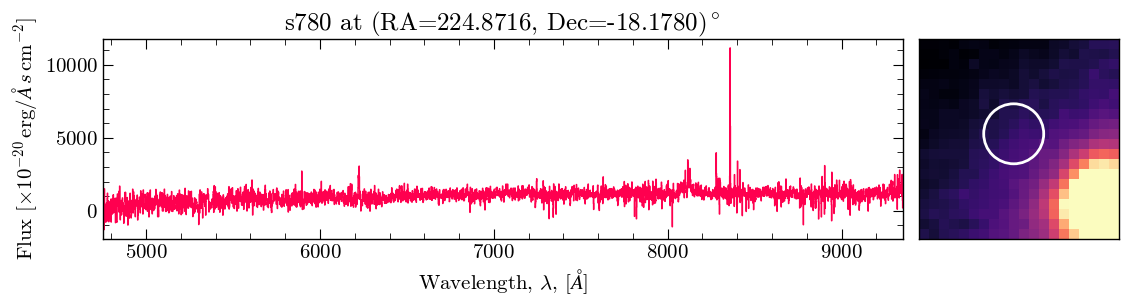

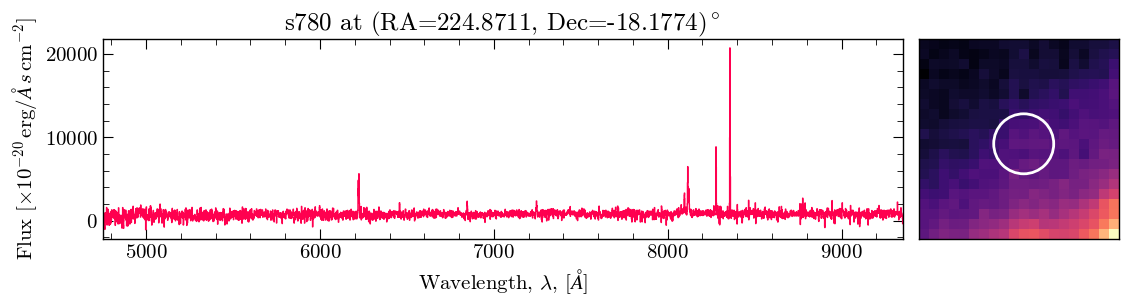

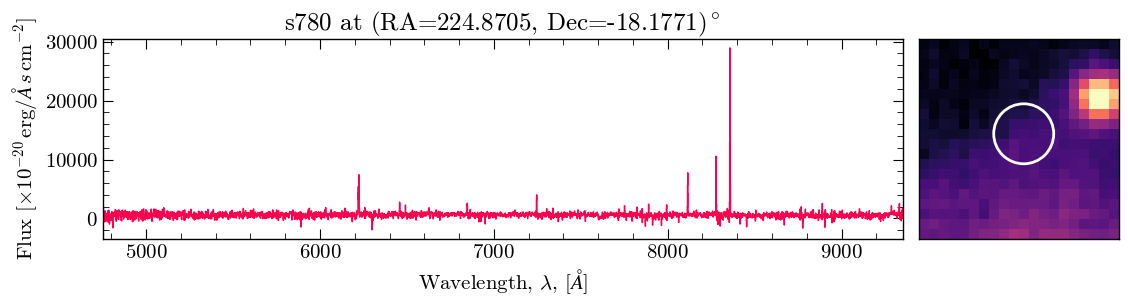

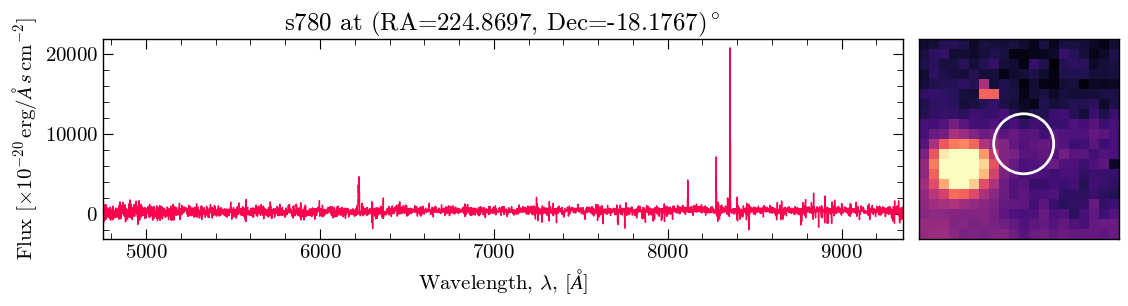

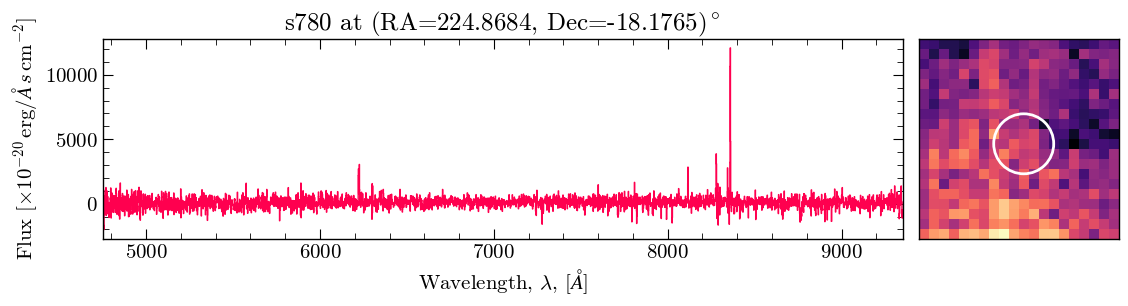

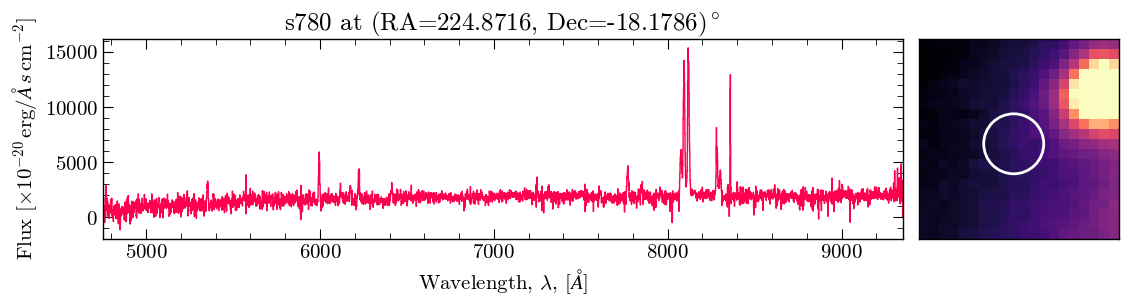

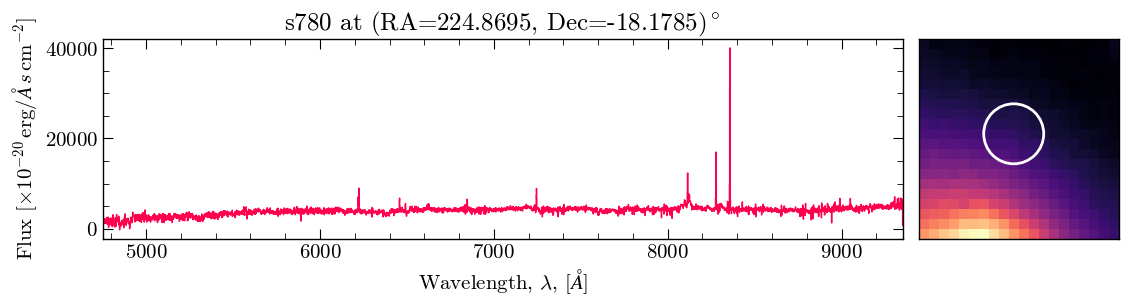

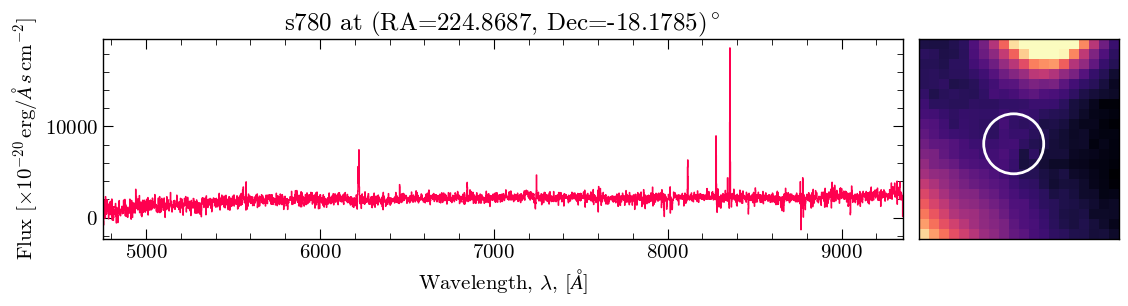

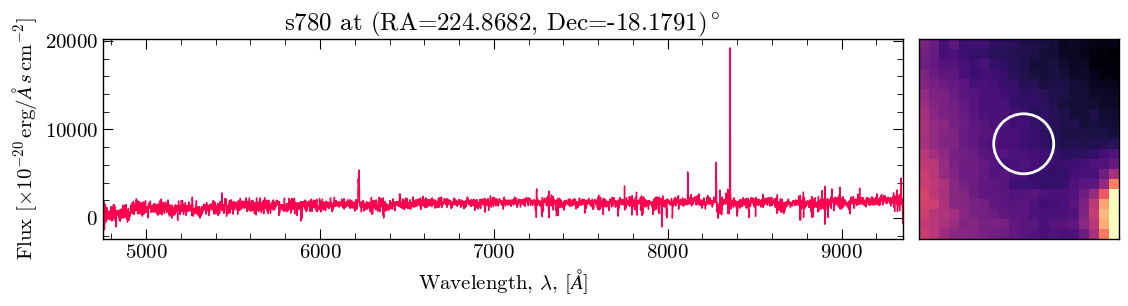

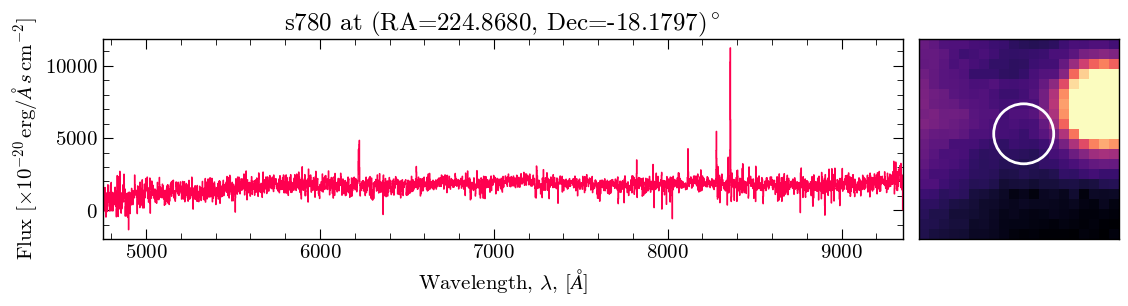

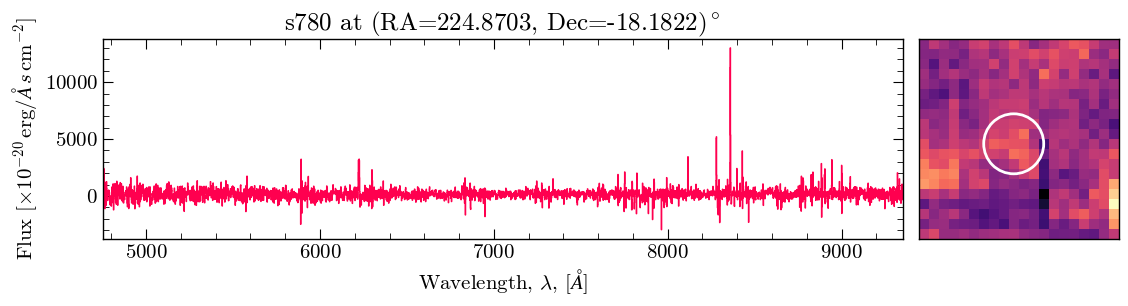

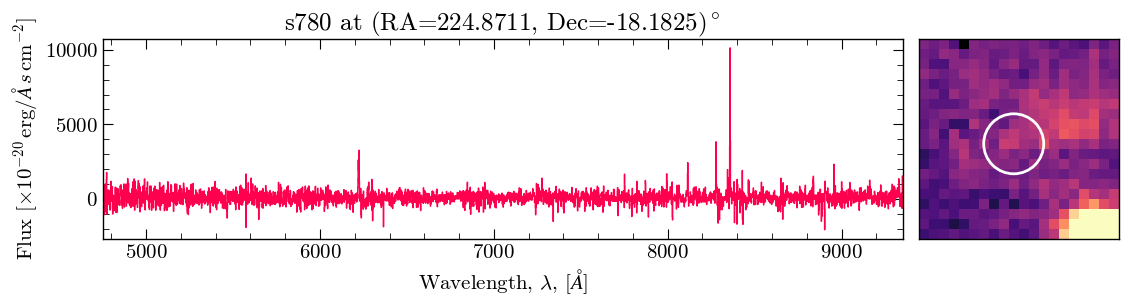

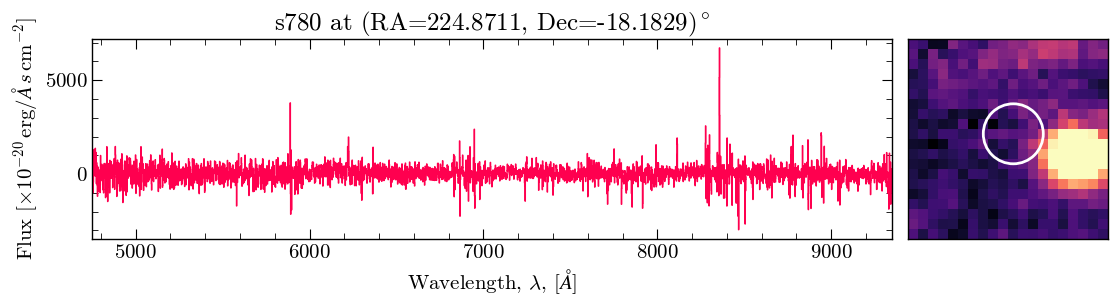

In [258]:
# spec = test.extract_spectrum(COORDS.ra.deg,COORDS.dec.deg, 0.6)
test.process_multiple_ds9('s780_coords.csv')

In [246]:
test.ex_table

object_id,ra,dec,z,oiii5007_flux,oiii5007_flux_err,oiii5007_ew,oiii5007_ew_err,oiii5007_centroid,oiii5007_fwhm,oiii4959_flux,oiii4959_flux_err,oiii4959_ew,oiii4959_ew_err,oiii4959_centroid,oiii4959_fwhm,oii3726_flux,oii3726_flux_err,oii3726_ew,oii3726_ew_err,oii3726_centroid,oii3726_fwhm,oii3729_flux,oii3729_flux_err,oii3729_ew,oii3729_ew_err,oii3729_centroid,oii3729_fwhm,halpha_flux,halpha_flux_err,halpha_ew,halpha_ew_err,halpha_centroid,halpha_fwhm,hbeta_flux,hbeta_flux_err,hbeta_ew,hbeta_ew_err,hbeta_centroid,hbeta_fwhm,hgamma_flux,hgamma_flux_err,hgamma_ew,hgamma_ew_err,hgamma_centroid,hgamma_fwhm,hdelta_flux,hdelta_flux_err,hdelta_ew,hdelta_ew_err,hdelta_centroid,hdelta_fwhm,oiii4363_flux,oiii4363_flux_err,oiii4363_ew,oiii4363_ew_err,oiii4363_centroid,oiii4363_fwhm,neiii_flux,neiii_flux_err,neiii_ew,neiii_ew_err,neiii_centroid,neiii_fwhm,nii6583_flux,nii6583_flux_err,nii6583_ew,nii6583_ew_err,nii6583_centroid,nii6583_fwhm,nii6548_flux,nii6548_flux_err,nii6548_ew,nii6548_ew_err,nii6548_centroid,nii6548_fwhm,sii6716_flux,sii6716_flux_err,sii6716_ew,sii6716_ew_err,sii6716_centroid,sii6716_fwhm,sii6731_flux,sii6731_flux_err,sii6731_ew,sii6731_ew_err,sii6731_centroid,sii6731_fwhm,heii4686_flux,heii4686_flux_err,heii4686_ew,heii4686_ew_err,heii4686_centroid,heii4686_fwhm,hei5876_flux,hei5876_flux_err,hei5876_ew,hei5876_ew_err,hei5876_centroid,hei5876_fwhm
str34,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
224d52m17pt6016s-18d10m40pt68516s,224.871556,-18.1779681,0.6695012973895351,14994.841340888735,1253.221794195918,7.844016021296381,0.655578249107899,5006.837907991957,1.4641827891270742,5201.933311265383,1013.4695488471173,4.469910887536563,0.8708528732515672,4958.81191781508,1.4050740869341456,9747.812420436036,1137.4675394374053,14.637810059666531,1.7080790102623051,3727.7836795107323,5.263573682917787,8900.38767049944,1106.3210549210257,12.136538290545333,1.5085756195979374,3727.812568359909,4.932197336620553,0.0,531.6441895650835,0.0,nan,6562.8,1.0,4473.271309577013,858.2062088605965,2.749973427317592,0.5275880013074312,4861.691409101793,2.2980390943763385,1244.9938579165048,1247.1640520914468,0.9564469121773183,0.9581141296533322,4340.365373228606,1.090705923304011,4592.880587615864,1185.9595679772992,5.102204710253711,1.3174756840445692,4103.1976099612775,10.392914228752172,330.3468036920249,nan,0.2782469036259221,nan,4362.963074050923,0.1839560276498191,2765.907082694019,695.274615294772,3.268301205707434,0.8215629793508354,3868.4282851411576,2.9235667752742645,0.0,531.6441895650835,0.0,nan,6583.45,1.0,0.0,531.6441895650835,0.0,nan,6548.05,1.0,0.0,531.6441895650835,0.0,nan,6716.44,1.0,0.0,531.6441895650835,0.0,nan,6730.82,1.0,628.3708127712438,301175099.3241776,0.45544615350149914,218293.14431821735,4689.068843480017,0.433052484284322,0.0,531.6441895650835,0.0,nan,5875.62,1.0
224d52m15pt84732s-18d10m38pt74692s,224.8710687,-18.1774297,0.6693569842453926,37495.11601872836,746.6425483926436,35.03726118979981,0.6976991342121474,5006.841795519234,1.7130149044298728,14244.72511898145,1044.3003527834742,14.8600446072165,1.0894102691399616,4958.852102625933,1.6807637369730795,21258.961818978063,2048.4067760266494,48.97617835781683,4.719098536716049,3727.6520757788217,4.660243765414331,17973.4485

In [230]:
test.title

's780'